#1. Import Dataset

In [ ]:
import tensorflow as tf


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/NO2_Land_Grid_Bangkok.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_NO2_MeanDaily_Bangkok_ADM1.csv")


#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# Pra-pemrosesan Data

In [ ]:
df.columns

In [ ]:
# df = no2_df.drop(columns=['Unnamed: 0'])
# df = df.drop(columns=['Unnamed: 0'])
# wind = wind.drop(columns=['Unnamed: 0'])

wind.dropna(inplace=True)
df.dropna(inplace = True)

In [ ]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,100.338063,13.682278,-0.755996,1.169993,1.392987,302.868698
3,2023-05-01,100.337941,13.708376,-0.755996,1.169993,1.392987,302.868698
4,2023-05-01,100.338148,13.721229,-0.755996,1.169993,1.392987,302.868698
6,2023-05-01,100.337116,13.747069,-0.803075,0.972524,1.261242,309.548640
7,2023-05-01,100.336273,13.758631,-0.803075,0.972524,1.261242,309.548640
...,...,...,...,...,...,...,...
1078932,2025-04-29,100.915276,13.942720,-0.804878,0.177327,0.824180,347.575309
1078934,2025-04-29,100.925230,13.807942,-0.815294,0.331706,0.880189,337.860854
1078935,2025-04-29,100.924874,13.819598,-0.815294,0.331706,0.880189,337.860854
1078938,2025-04-29,100.932461,13.807774,-0.815294,0.331706,0.880189,337.860854


In [ ]:
df

,date,mean,longitude,latitude
1,2023-05-01,0.000144,100.338063,13.682278
3,2023-05-01,0.000144,100.337941,13.708376
4,2023-05-01,0.000144,100.338148,13.721229
6,2023-05-01,0.000139,100.337116,13.747069
7,2023-05-01,0.000139,100.336273,13.758631
...,...,...,...,...
1078932,2025-04-29,0.000094,100.915276,13.942720
1078934,2025-04-29,0.000089,100.925230,13.807942
1078935,2025-04-29,0.000089,100.924874,13.819598
1078938,2025-04-29,0.000089,100.932461,13.807774


In [ ]:
df['date'] = pd.to_datetime(df['date'])  #format date
start_date = datetime.datetime(2023, 5, 1) #pastikan tanggal mulainya benar
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"}) #rename kolom supaya sama antara df dan wind
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True) #rapikan urutan tanggal, garis bujur, dan garis lintang

In [ ]:
df.describe()

,date,mean,x_coord,y_coord
count,988509,988509.000000,988509.000000,988509.000000
mean,2024-04-29 22:21:38.369969152,0.000118,100.626057,13.771305
min,2023-05-01 00:00:00,0.000006,100.336059,13.499631
25%,2023-10-31 00:00:00,0.000083,100.484930,13.709142
50%,2024-04-29 00:00:00,0.000104,100.626455,13.770892
75%,2024-10-29 00:00:00,0.000136,100.760117,13.844992
max,2025-04-29 00:00:00,0.000740,100.932461,13.951460
std,NaN,0.000056,0.162580,0.094907


In [ ]:
wind.describe()

,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06
mean,1.006292e+02,1.377479e+01,2.768018e-01,7.499333e-01,2.105402e+00,1.866070e+02
std,1.619868e-01,9.111033e-02,1.379507e+00,1.658528e+00,9.275282e-01,9.525569e+01
min,1.003361e+02,1.350122e+01,-4.674856e+00,-4.757746e+00,1.552426e-02,1.286865e-01
25%,1.004928e+02,1.370914e+01,-6.348260e-01,-5.604215e-01,1.455094e+00,7.402554e+01
50%,1.006338e+02,1.377089e+01,1.586177e-01,1.055008e+00,2.146151e+00,2.213204e+02
75%,1.007680e+02,1.384499e+01,1.245951e+00,1.960712e+00,2.754169e+00,2.619604e+02
max,1.009325e+02,1.395146e+01,5.253960e+00,6.101706e+00,6.105534e+00,3.599608e+02


## Pembersihan Data Polusi

In [ ]:
# no2_df = no2_df[no2_df.NO2_mean>=0]
df=df.rename(columns={"mean":"NO2_mean"})

# Pembersihan Data
df = df[df["NO2_mean"]>=0]

wind['date'] = pd.to_datetime(wind['date'])

#Gabungkan data polutan dengan data keceparan arah angin (sudah dikonversi jadi wx dan wy)
merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

,date,NO2_mean,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
0,2023-05-01,0.000142,100.343405,13.721492,-0.714126,1.163645,1.365301,301.537324
1,2023-05-01,0.000142,100.343405,13.733842,-0.714126,1.163645,1.365301,301.537324
2,2023-05-01,0.000142,100.343405,13.709142,-0.714126,1.163645,1.365301,301.537324
3,2023-05-01,0.000151,100.343405,13.783242,-0.765924,0.952016,1.221874,308.817680
4,2023-05-01,0.000151,100.343405,13.746192,-0.765924,0.952016,1.221874,308.817680


## Rata-rata Kecepatan Angin

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

#Untuk setiap koordinat (x,y), rata-ratakan kecepatan angin wx dan wy sepanjang waktu
merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,0.000120,0.283523,0.748113,100.613907,13.767418
min,2023-05-01 00:00:00,0.000009,0.047809,0.596048,100.343405,13.511542
25%,2023-10-31 00:00:00,0.000084,0.241943,0.679754,100.477067,13.709142
50%,2024-04-29 00:00:00,0.000105,0.292260,0.729230,100.595005,13.770892
75%,2024-10-29 00:00:00,0.000139,0.329148,0.784429,100.744392,13.820292
max,2025-04-29 00:00:00,0.000740,0.446781,1.127054,100.925230,13.943792
std,NaN,0.000058,0.064678,0.088489,0.171918,0.083353


/tmp/ipython-input-4235630030.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  thailand['centroid'] = thailand.geometry.centroid
/tmp/ipython-input-4235630030.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


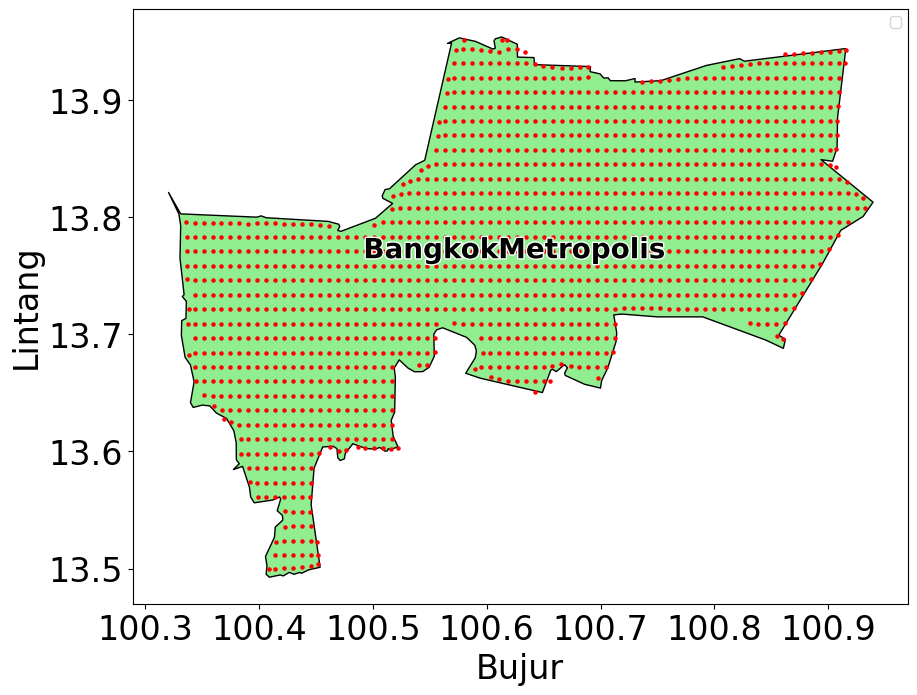

In [ ]:
import geopandas as gpd
thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

from shapely.geometry import Point
import matplotlib.patheffects as pe

# Create geometry column in df
df['geometry'] = [Point(xy) for xy in zip(df['x_coord'], df['y_coord'])]
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

thailand['centroid'] = thailand.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(10,10))
thailand.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

for idx, row in thailand.iterrows():
          ax.annotate(
              text=row['NAME_1'],
              xy=(row['centroid'].x, row['centroid'].y),
              ha='center', va='center',
              fontsize=20, color='black', weight='bold',
              path_effects=[pe.withStroke(linewidth=2, foreground="white")]
          )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime, timedelta

df['time'] = (df['date'] - df['date'].min()).dt.days

start_date = datetime(2023, 5, 1)

target_day = 8
target_month = 1
target_year = 2025

target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

time_to_visualize = t

df_visualize = df[df['time'] == time_to_visualize].copy()
if df_visualize.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {df_visualize.shape}")
    display(df_visualize.head())

    thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
    thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()


Jumlah Koordinat Unik: 1393

Merged GeoDataFrame:


/tmp/ipython-input-1453563276.py:6: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, thailand, how="inner", predicate="within")


,date,NO2_mean,x_coord,y_coord,time,geometry,index_right,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
913414,2025-01-08,0.000182,100.336059,13.795655,618,POINT (100.33606 13.79565),2,THA.3_1,THA,Thailand,BangkokMetropolis,Bangkok|KrungThep|KrungThepMa,จังหวัดเชียงใหม่,Changwat,Province,10,TH.BM,NA
913411,2025-01-08,0.000182,100.336273,13.758631,618,POINT (100.33627 13.75863),2,THA.3_1,THA,Thailand,BangkokMetropolis,Bangkok|KrungThep|KrungThepMa,จังหวัดเชียงใหม่,Changwat,Province,10,TH.BM,NA
913412,2025-01-08,0.000182,100.336403,13.770735,618,POINT (100.3364 13.77074),2,THA.3_1,THA,Thailand,BangkokMetropolis,Bangkok|KrungThep|KrungThepMa,จังหวัดเชียงใหม่,Changwat,Province,10,TH.BM,NA
913413,2025-01-08,0.000182,100.336482,13.783399,618,POINT (100.33648 13.7834),2,THA.3_1,THA,Thailand,BangkokMetropolis,Bangkok|KrungThep|KrungThepMa,จังหวัดเชียงใหม่,Changwat,Province,10,TH.BM,NA
913410,2025-01-08,0.000182,100.337116,13.747069,618,POINT (100.33712 13.74707),2,THA.3_1,THA,Thailand,BangkokMetropolis,Bangkok|KrungThep|KrungThepMa,จังหวัดเชียงใหม่,Changwat,Province,10,TH.BM,NA


/tmp/ipython-input-1453563276.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  thailand['centroid'] = thailand.geometry.centroid


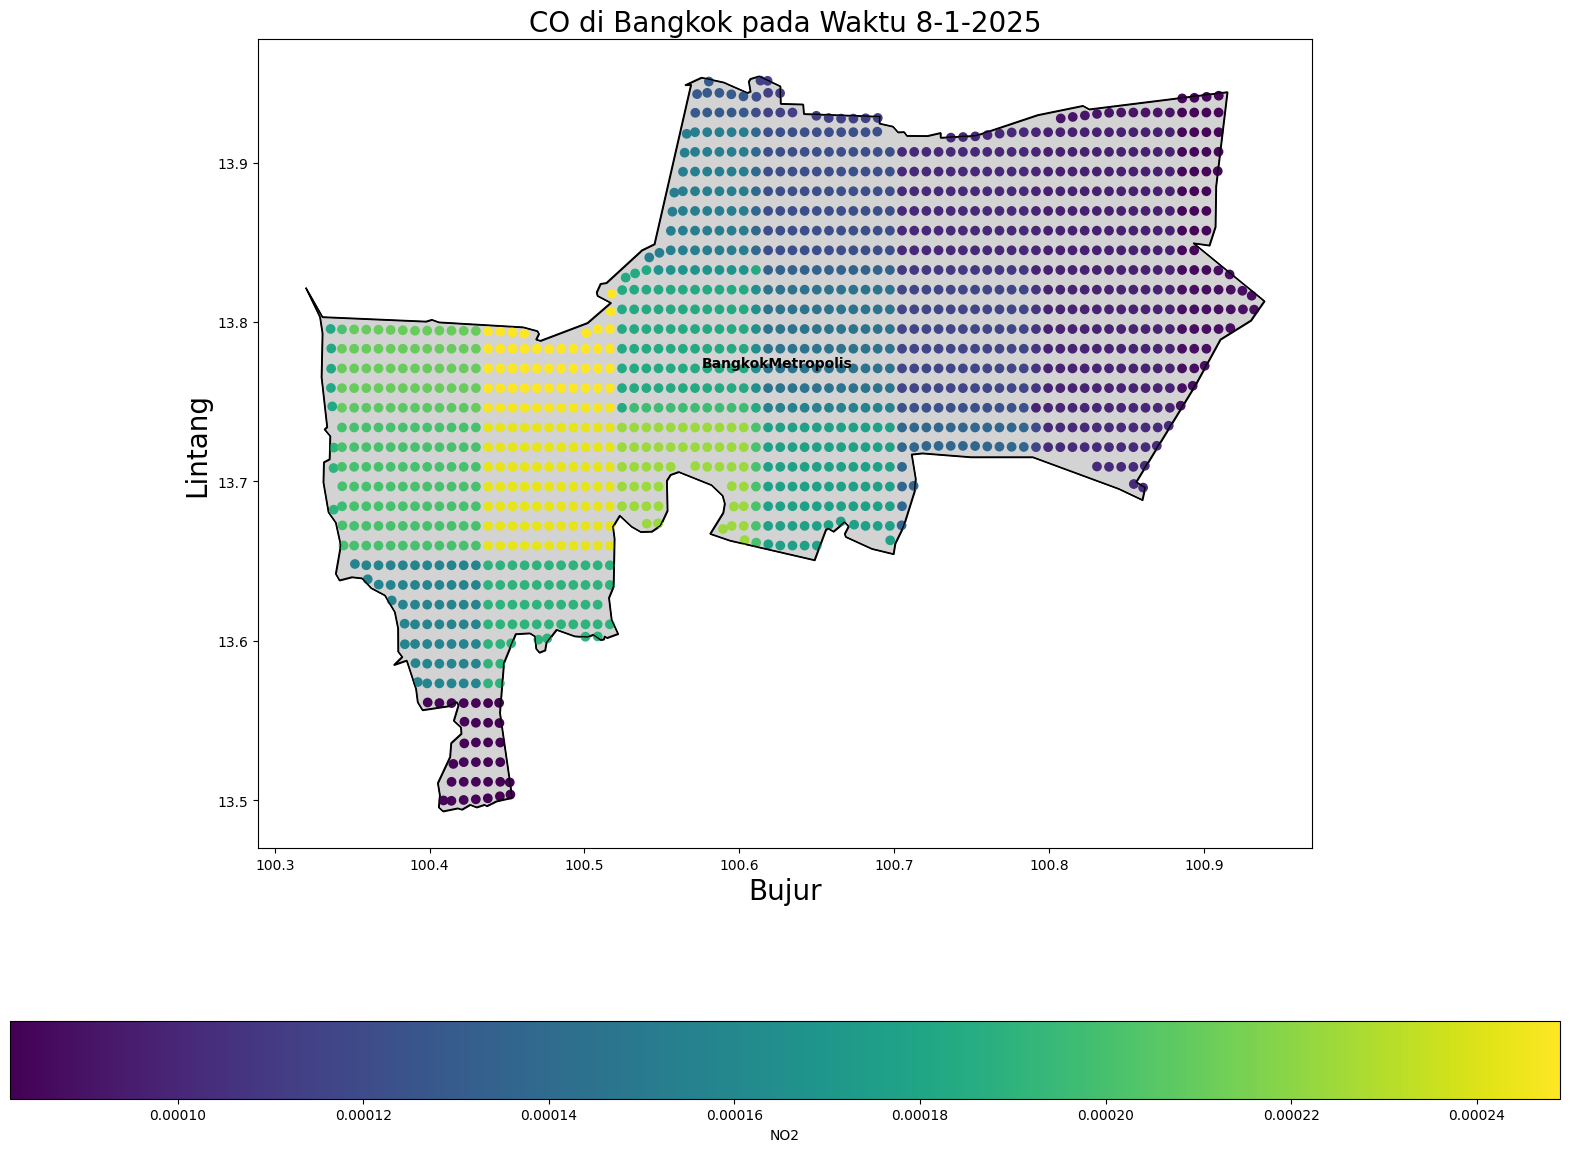

In [ ]:

    # --- 4. Merge Data ---
    # Create a GeoDataFrame from the filtered prediction data
    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
    print("Jumlah Koordinat Unik:", len(geometry))
    merged_gdf = gpd.sjoin(gdf, thailand, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())


    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(1, 1, figsize=(20, 15))

    # Plot the base map of Java with edge boundaries
    thailand.plot(ax=ax, color='lightgray', edgecolor='black')

    if not merged_gdf.empty:
        merged_gdf.plot(column='NO2_mean', ax=ax, legend=True,
                        cmap='viridis',
                        legend_kwds={'label': "NO2",
                                    'orientation': "horizontal"})

    # --- Tambahkan nama kota/kabupaten ---
    # Hitung centroid dari setiap polygon
    thailand.boundary.plot(ax=ax, color='black', linewidth=1)

    thailand['centroid'] = thailand.geometry.centroid

    # Tambahkan teks nama kota/kabupaten pada posisi centroid
    for idx, row in thailand.iterrows():
        plt.annotate(text=row['NAME_1'],
                    xy=(row['centroid'].x, row['centroid'].y),
                    horizontalalignment='center',
                    fontsize=10,
                    color='black',
                    weight='bold')

    # Set plot title and labels
    ax.set_title(f'NO2 di Bangkok pada Waktu {target_day}-{target_month}-{target_year}', fontsize=20)
    ax.set_xlabel('Bujur', fontsize=20)
    ax.set_ylabel('Lintang', fontsize=20)

    plt.show()


In [ ]:
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_NO2.csv")

In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_NO2.csv",index_col=0)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

## Teknik Rescaling

In [ ]:
df

,date,NO2_mean,u10,v10,x_coord,y_coord
0,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.721492
1,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.733842
2,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.709142
3,2023-05-01,0.000151,0.303668,0.679754,100.343405,13.783242
4,2023-05-01,0.000151,0.303668,0.679754,100.343405,13.746192
...,...,...,...,...,...,...
423565,2025-04-29,0.000089,0.132474,0.638082,100.909505,13.820292
423566,2025-04-29,0.000089,0.132474,0.638082,100.917098,13.796169
423567,2025-04-29,0.000089,0.132474,0.638082,100.917367,13.820292
423568,2025-04-29,0.000089,0.132474,0.638082,100.917367,13.807942


In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,0.000120,0.283523,0.748113,100.613907,13.767418
min,2023-05-01 00:00:00,0.000009,0.047809,0.596048,100.343405,13.511542
25%,2023-10-31 00:00:00,0.000084,0.241943,0.679754,100.477067,13.709142
50%,2024-04-29 00:00:00,0.000105,0.292260,0.729230,100.595005,13.770892
75%,2024-10-29 00:00:00,0.000139,0.329148,0.784429,100.744392,13.820292
max,2025-04-29 00:00:00,0.000740,0.446781,1.127054,100.925230,13.943792
std,NaN,0.000058,0.064678,0.088489,0.171918,0.083353


In [ ]:
#Ubah dari tanggal ke dalam numerik
df['time'] = (df['date'] - df['date'].min()).dt.days

#Teknik Rescaling
scale = 1e-5
df.NO2_mean = df.NO2_mean/scale

df['x_coord'] = df['x_coord'] * 100
df['y_coord'] = df['y_coord'] * 100

## Lowpass Filtering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.45):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real



full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
coords = df[['x_coord', 'y_coord']].drop_duplicates()
full_index = pd.MultiIndex.from_frame(
    coords.merge(pd.DataFrame({'date': full_dates}), how='cross')
)

df2 = (
    df.set_index(['x_coord', 'y_coord', 'date'])
    .reindex(full_index)
    .reset_index()
    .rename(columns={'level_0': 'x_coord', 'level_1': 'y_coord', 'level_2': 'date'})
)

df2['NO2_mean'] = (df2.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['NO2_filtered'] = df.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(low_pass_filter)
df = df[['date', 'NO2_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    df[['date', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

# 'df' now contains the new 'NO2_filtered' column with the results.
print(df.head())

        date   NO2_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1372.14918     0   
1 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1373.38418     0   
2 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1370.91418     0   
3 2023-05-01  15.088663  0.303668  0.679754  10034.340462  1378.32418     0   
4 2023-05-01  15.088663  0.303668  0.679754  10034.340462  1374.61918     0   

   NO2_filtered  
0     14.088170  
1     14.088170  
2     14.088170  
3     14.238412  
4     14.238412  


In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,0.283523,0.748113,10061.390695,1376.741780,364.882515,12.020415
min,2023-05-01 00:00:00,0.870819,0.047809,0.596048,10034.340462,1351.154180,0.000000,1.558087
25%,2023-10-31 00:00:00,8.366587,0.241943,0.679754,10047.706712,1370.914180,183.000000,8.339682
50%,2024-04-29 00:00:00,10.505674,0.292260,0.729230,10059.500462,1377.089180,364.000000,10.556475
75%,2024-10-29 00:00:00,13.892418,0.329148,0.784429,10074.439212,1382.029180,547.000000,13.973814
max,2025-04-29 00:00:00,73.968811,0.446781,1.127054,10092.522962,1394.379180,729.000000,67.505884
std,NaN,5.797119,0.064678,0.088489,17.191771,8.335325,210.488126,5.680008


In [ ]:
from scipy.stats import kstest
import pandas as pd

# Assume 'filtered_df' is your DataFrame with NO2_mean and NO2_filtered columns

def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['NO2_mean'] - group['NO2_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10034.340462  1372.14918             0.138184  2.961547e-12   Not Gaussian   
1  10034.340462  1373.38418             0.138184  2.961547e-12   Not Gaussian   
2  10034.340462  1370.91418             0.138184  2.961547e-12   Not Gaussian   
3  10034.340462  1378.32418             0.102713  5.767209e-07   Not Gaussian   
4  10034.340462  1374.61918             0.102713  5.767209e-07   Not Gaussian   

   Data Points  
0          708  
1          708  
2          708  
3          709  
4          709  


/tmp/ipython-input-1439980828.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,395
Not Gaussian,202


In [ ]:
import matplotlib.pyplot as plt

# Filter locations with 'Not Gaussian' residuals
not_gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Not Gaussian'][['x_coord', 'y_coord']]

# Select up to 20 unique locations randomly
selected_locations = not_gaussian_locations.sample(min(20, len(not_gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = df[(df['x_coord'] == x_c) & (df['y_coord'] == y_c)].copy()

    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # Plotting
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f'NO2 Data, Filtered Data, and Residuals for Location ({x_c:.2f}, {y_c:.2f})', fontsize=16)

    # Plot original NO2_mean
    axes[0].plot(location_data['time'], location_data['NO2_mean'], label='Original NO2 Mean', color='blue')
    axes[0].set_ylabel('NO2 Mean')
    axes[0].legend()
    axes[0].grid(True)

    # Plot NO2_filtered
    axes[1].plot(location_data['time'], location_data['NO2_filtered'], label='NO2 Filtered', color='green')
    axes[1].set_ylabel('NO2 Filtered')
    axes[1].legend()
    axes[1].grid(True)

    # Plot residuals
    axes[2].plot(location_data['time'], location_data['residuals'], label='Residuals', color='red')
    axes[2].set_ylabel('Residuals')
    axes[2].set_xlabel('Time (days)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    fig = plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], label='Residuals',bins=40, color='blue', alpha=0.7)
    plt.title(f'Distribution of Residuals for Location ({x_c:.2f}, {y_c:.2f}')


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,0.283523,0.748113,10061.390695,1376.741780,364.882515,12.020415
min,2023-05-01 00:00:00,0.870819,0.047809,0.596048,10034.340462,1351.154180,0.000000,1.558087
25%,2023-10-31 00:00:00,8.366587,0.241943,0.679754,10047.706712,1370.914180,183.000000,8.339682
50%,2024-04-29 00:00:00,10.505674,0.292260,0.729230,10059.500462,1377.089180,364.000000,10.556475
75%,2024-10-29 00:00:00,13.892418,0.329148,0.784429,10074.439212,1382.029180,547.000000,13.973814
max,2025-04-29 00:00:00,73.968811,0.446781,1.127054,10092.522962,1394.379180,729.000000,67.505884
std,NaN,5.797119,0.064678,0.088489,17.191771,8.335325,210.488126,5.680008


In [ ]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
0,2023-05-01,14.160173,10034.340462,1372.149180,0,14.088170,0.348237,0.784429
1,2023-05-01,14.160173,10034.340462,1373.384180,0,14.088170,0.348237,0.784429
2,2023-05-01,14.160173,10034.340462,1370.914180,0,14.088170,0.348237,0.784429
3,2023-05-01,15.088663,10034.340462,1378.324180,0,14.238412,0.303668,0.679754
4,2023-05-01,15.088663,10034.340462,1374.619180,0,14.238412,0.303668,0.679754
...,...,...,...,...,...,...,...,...
423565,2025-04-29,8.945238,10090.950462,1382.029180,729,9.265307,0.132474,0.638082
423566,2025-04-29,8.945238,10091.709823,1379.616872,729,9.265307,0.132474,0.638082
423567,2025-04-29,8.945238,10091.736712,1382.029180,729,9.265307,0.132474,0.638082
423568,2025-04-29,8.945238,10091.736712,1380.794180,729,9.265307,0.132474,0.638082


In [ ]:
filtered_df.describe()

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,10061.390695,1376.741780,364.882515,12.020415,0.283523,0.748113
min,2023-05-01 00:00:00,0.870819,10034.340462,1351.154180,0.000000,1.558087,0.047809,0.596048
25%,2023-10-31 00:00:00,8.366587,10047.706712,1370.914180,183.000000,8.339682,0.241943,0.679754
50%,2024-04-29 00:00:00,10.505674,10059.500462,1377.089180,364.000000,10.556475,0.292260,0.729230
75%,2024-10-29 00:00:00,13.892418,10074.439212,1382.029180,547.000000,13.973814,0.329148,0.784429
max,2025-04-29 00:00:00,73.968811,10092.522962,1394.379180,729.000000,67.505884,0.446781,1.127054
std,NaN,5.797119,17.191771,8.335325,210.488126,5.680008,0.064678,0.088489


# Split Train Testing

In [ ]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(296499, 3), dtype=float32, numpy=
array([[  594.    , 10087.806 ,  1383.2642],
       [  196.    , 10052.424 ,  1375.8541],
       [  695.    , 10068.936 ,  1378.3242],
       ...,
       [   66.    , 10087.02  ,  1391.9092],
       [  307.    , 10081.516 ,  1389.4392],
       [  319.    , 10060.287 ,  1391.9092]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(127071, 3), dtype=float32, numpy=
array([[  437.    , 10037.485 ,  1369.6792],
       [   95.    , 10068.936 ,  1379.5592],
       [  179.    , 10072.08  ,  1383.2642],
       ...,
       [  228.    , 10067.363 ,  1372.1492],
       [  254.    , 10067.363 ,  1369.6792],
       [  211.    , 10083.874 ,  1390.6742]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[ 9.155551 ],
       [ 5.6641955],
       [ 9.98596  ],
       ...,
       [11.616995 ],
       [ 7.880227 ],
       [14.885566 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(127071, 1), dtype=float32, numpy=
array([[ 6.6868205],
       [ 8.387415 ],
       [10.5220995],
       ...,
       [14.790911 ],
       [23.52237  ],
       [ 7.0822496]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[0.19223039],
       [0.2922604 ],
       [0.27202746],
       ...,
       [0.17678893],
       [0.17678893],
       [0.25660715]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[0.6816191 ],
       [0.72923046],
       [0.7406938 ],
       ...,
       [0.64210343],
       [0.64210343],
       [0.64908916]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
ub-lb

array([729.        ,  58.18250001,  43.22499991])

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':140,'activation':'swish', 'trainable_B':True, 'sigmas':[3,5], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*W_v * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8, N_fwd=None)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



Forward optimization (full dataset)


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Iteration 1, Loss: 176.81478881835938
Iteration 2, Loss: 151.22647094726562
Iteration 3, Loss: 39.930625915527344
Iteration 4, Loss: 40.990089416503906
Iteration 5, Loss: 61.7784538269043
Iteration 6, Loss: 66.7677230834961
Iteration 7, Loss: 52.05549240112305
Iteration 8, Loss: 32.12725830078125
Iteration 9, Loss: 30.07893180847168
Iteration 10, Loss: 39.33686065673828
Iteration 11, Loss: 26.0192813873291
Iteration 12, Loss: 26.776573181152344
Iteration 13, Loss: 29.058673858642578
Iteration 14, Loss: 27.957443237304688
Iteration 15, Loss: 24.272851943969727
Iteration 16, Loss: 22.1141357421875
Iteration 17, Loss: 24.231945037841797
Iteration 18, Loss: 24.153303146362305
Iteration 19, Loss: 21.485136032104492
Iteration 20, Loss: 21.17607879638672
Iteration 21, Loss: 22.062490463256836
Iteration 22, Loss: 22.262617111206055
Iteration 23, Loss: 21.50189971923828
Iteration 24, Loss: 20.597518920898438
Iteration 25, Loss: 20.4803466796875
Iteration 26, Loss: 20.899120330810547
Iteration 2

KeyboardInterrupt: 

In [ ]:
path = dir + "NO2Model/Fourier/Bangkok_Fourier_inv_swish/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models
initial_lambdas = [0.5]
for i in range(60):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


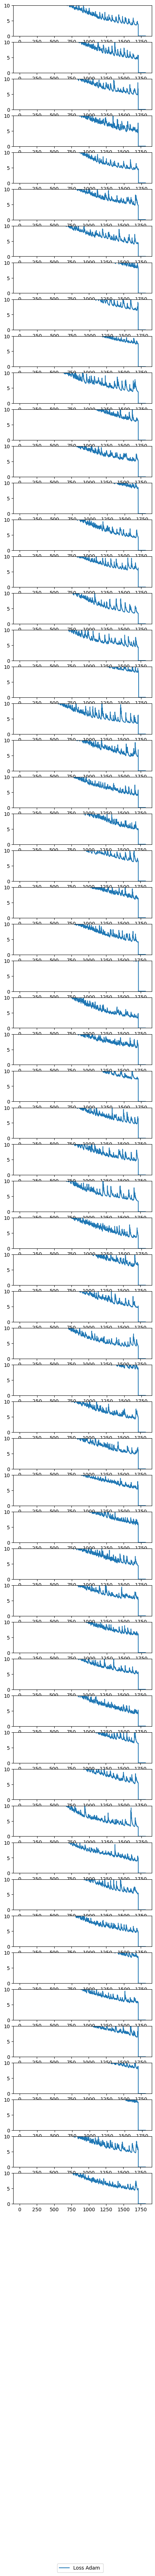

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,10])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,5])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,5])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,5])

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.468095
Attempt 2,0.413627
Attempt 3,0.249980
Attempt 4,0.417035
Attempt 5,0.277794
Attempt 6,0.409374
Attempt 7,0.297056
Attempt 8,0.406759
Attempt 9,0.403000
Attempt 10,0.360986


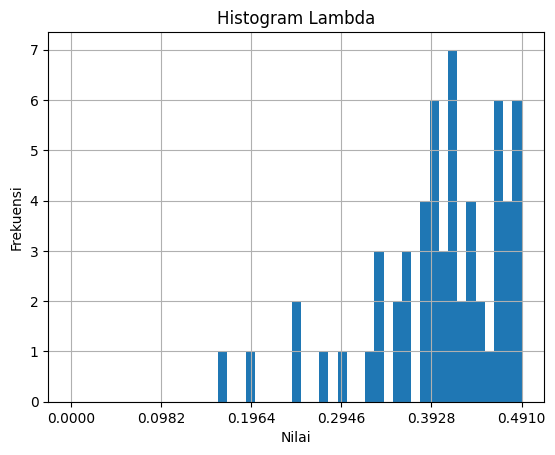

In [ ]:
bins = np.linspace(1e-5,max(df.Adam),50)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=bins, align='mid')

plt.xticks(np.linspace(1e-5, max(df.Adam), 6))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Lambda")
plt.grid(True)
plt.show()

In [ ]:
df.describe()

,Adam
count,60.000000
mean,0.402992
std,0.071907
min,0.164011
25%,0.377924
50%,0.414130
75%,0.465998
max,0.491030


/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


beta         KS=0.0962, p=0.6014, params=(np.float64(3.785274417747475), np.float64(0.9446727832071926), np.float64(0.04149365214429932), np.float64(0.44953641506112973))
gengamma     KS=0.0995, p=0.558, params=(np.float64(0.005405662788817704), np.float64(821.4022291667566), np.float64(0.010452218303259727), np.float64(0.4812474570228924))
fisk         KS=0.1094, p=0.4386, params=(np.float64(2030415.64655388), np.float64(-77234.23637823717), np.float64(77234.64763090284))
burr         KS=0.1169, p=0.3571, params=(np.float64(839.2630334669539), np.float64(0.008252208918327796), np.float64(-0.20579732720850896), np.float64(0.6971996681136527))
norm         KS=0.1344, p=0.2085, params=(np.float64(0.4029924042522907), np.float64(0.07130551159131868))
lognorm      KS=0.1344, p=0.2085, params=(np.float64(4.3520914633075546e-06), -16383.835989207011, np.float64(16384.238981456103))
invgauss     KS=0.1747, p=0.04514, params=(np.float64(0.008898729400527116), np.float64(-0.4476718645896979), n

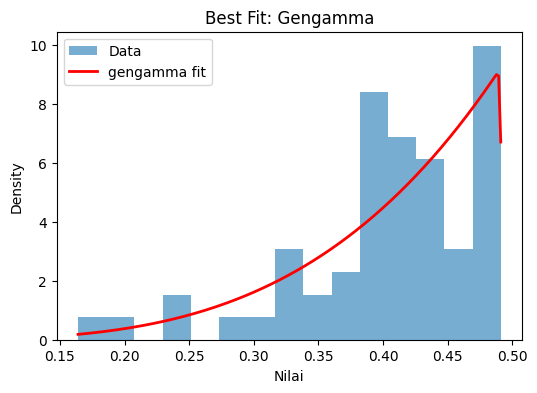

Mean: 0.4029674879840506


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[1]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.gengamma.fit(data)
mean = stats.gengamma.mean(*params)
print("Mean:", mean)

In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.402992
dtype: float64
             Adam
Average  0.402992
StdDev   0.071306
CV       0.176940


# Pelatihan Kasus Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':140,'activation':'swish', 'trainable_B':True, 'sigmas':[3.0,5.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

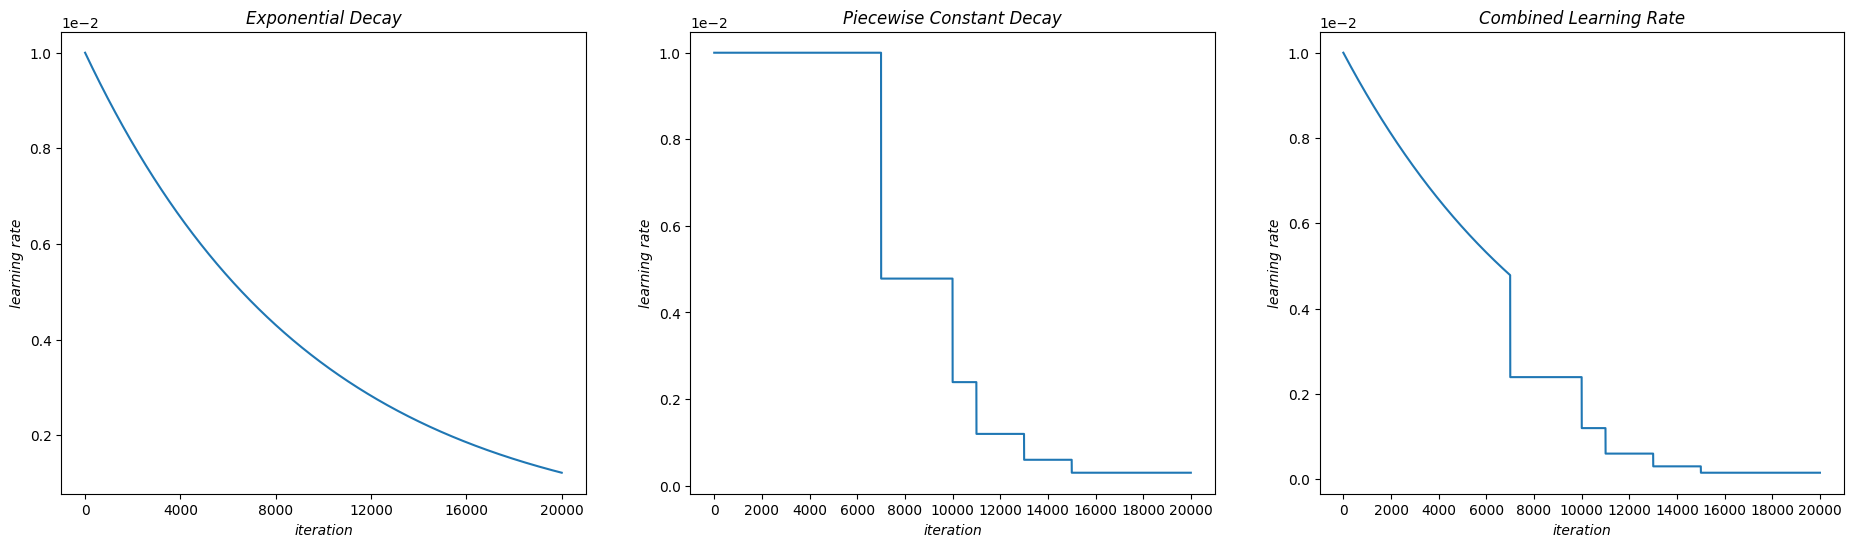

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
pred_lambda = [0.4029674879840506]


In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout, batch_size = 4096)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 7.20110527e-10 Data Loss: 10.2356672 Total Loss: 102.356674
PDE Loss: 6.80145273e-10 Data Loss: 9.63145447 Total Loss: 96.3145447
PDE Loss: 6.63449407e-10 Data Loss: 8.68010712 Total Loss: 86.8010712
PDE Loss: 5.98552763e-10 Data Loss: 9.94236565 Total Loss: 99.4236603
PDE Loss: 8.45690906e-10 Data Loss: 8.90253353 Total Loss: 89.0253372
PDE Loss: 7.84386556e-10 Data Loss: 9.34392071 Total Loss: 93.439209
PDE Loss: 7.24982296e-10 Data Loss: 9.19987679 Total Loss: 91.998764
PDE Loss: 8.95818419e-10 Data Loss: 9.76989746 Total Loss: 97.6989746
PDE Loss: 7.72434561e-10 Data Loss: 9.45532513 Total Loss: 94.5532532
PDE Loss: 6.54754861e-10 Data Loss: 9.76174641 Total Loss: 97.6174622
PDE Loss: 7.94678212e-10 Data Loss: 10.1482172 Total Loss: 101.48217
PDE Loss: 1.22001254e-09 Data Loss: 9.17052078 Total Loss: 91.7052078
PDE Loss: 1.0697585e-09 Data Loss: 9.18607807 Total Loss: 91.8607788
PDE Loss: 7.66071317e-10 Data Loss: 9.60809

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 4.36958747e-10 Data Loss: 10.6140366 Total Loss: 106.140366
PDE Loss: 4.26563174e-10 Data Loss: 10.9548798 Total Loss: 109.548798
PDE Loss: 4.13248796e-10 Data Loss: 10.3908195 Total Loss: 103.908195
PDE Loss: 4.66347849e-10 Data Loss: 10.3993664 Total Loss: 103.993668
PDE Loss: 6.03046724e-10 Data Loss: 12.381382 Total Loss: 123.81382
PDE Loss: 4.62219873e-10 Data Loss: 10.0233078 Total Loss: 100.233078
PDE Loss: 6.73608e-10 Data Loss: 11.3397474 Total Loss: 113.397476
PDE Loss: 4.2886647e-10 Data Loss: 10.285429 Total Loss: 102.854294
PDE Loss: 4.39295711e-10 Data Loss: 10.4569359 Total Loss: 104.569359
PDE Loss: 4.57313437e-10 Data Loss: 10.6304789 Total Loss: 106.304787
PDE Loss: 4.45412263e-10 Data Loss: 10.5457401 Total Loss: 105.457397
PDE Loss: 5.7020666e-10 Data Loss: 9.5725832 Total Loss: 95.7258301
PDE Loss: 5.5127769e-10 Data Loss: 10.9457207 Total Loss: 109.457207
PDE Loss: 5.04747799e-10 Data Loss: 9.54264545 To

In [ ]:
path = dir + "NO2Model/Fourier/Bangkok_Fourier_fwd_swish/"

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [ ]:
n_models = 5

models_Adam_comb = [None] * n_models

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )

hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_9', howeve

## Grafik Loss

len Atempt-0 Lambda ke- 0:  122
\\
len Atempt-1 Lambda ke- 0:  121
\\
len Atempt-2 Lambda ke- 0:  124
\\
len Atempt-3 Lambda ke- 0:  124
\\
len Atempt-4 Lambda ke- 0:  124
\\


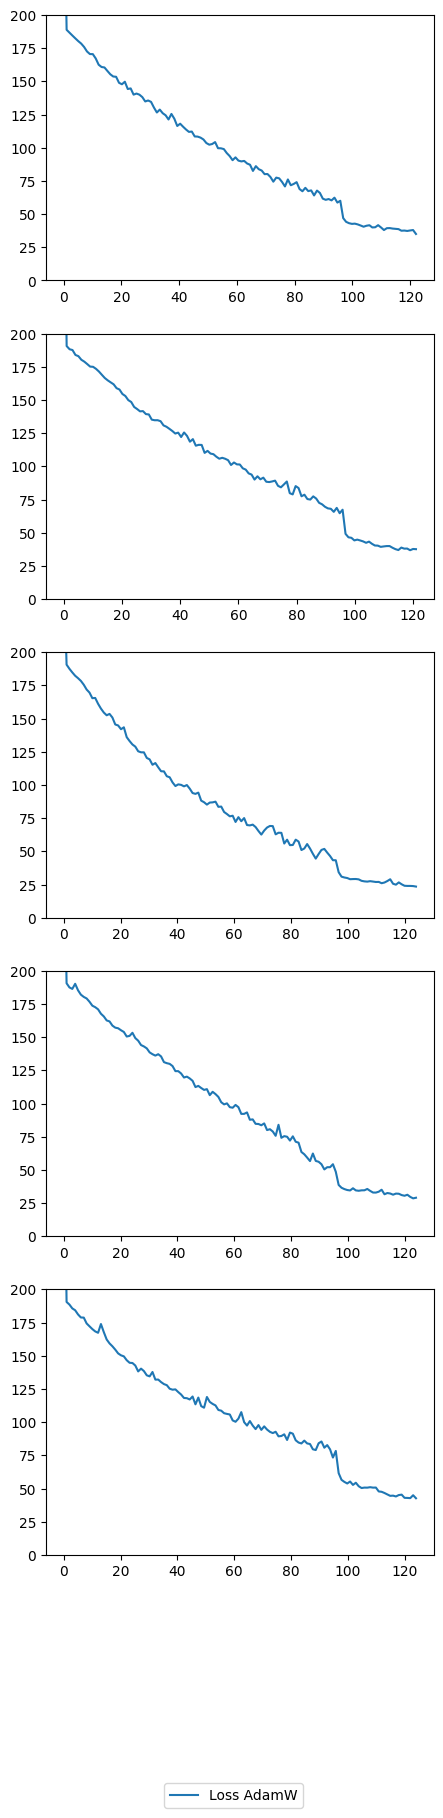

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,2e2])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.2363284, 11.3307085)"
Attempt 2,"(1.3185556, 12.058212)"
Attempt 3,"(1.0278018, 9.600637)"
Attempt 4,"(1.1661625, 10.858226)"
Attempt 5,"(1.415627, 13.007547)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.3229756, 12.068691)"
Attempt 2,"(1.4080111, 12.813161)"
Attempt 3,"(1.1077921, 10.318052)"
Attempt 4,"(1.2575904, 11.674668)"
Attempt 5,"(1.5071212, 13.766999)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE   cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  1.320698  0.151405  0.11464  12.128314  1.288478  0.106237


In [ ]:
weights = models_Adam_comb[0][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-2.36440241e-01  3.59125042e+00  5.93496275e+00 -1.73216367e+00
  -8.49412560e-01  7.01580197e-02 -1.14227974e+00  4.64739847e+00
  -1.98413742e+00 -7.46921171e-03 -9.75914121e-01 -5.94581461e+00
  -6.80767250e+00  5.15516520e+00  7.36057520e-01  9.59764957e-01
   2.08814287e+00 -4.89381999e-01 -5.21601319e-01  3.55073237e+00
   3.02727008e+00  6.28574312e-01  1.79367435e+00 -1.35037827e+00
   1.86740601e+00 -4.58898216e-01  1.33280325e+00  1.30048227e+00
   2.24234140e-03 -1.30381966e+00 -1.41776776e+00  3.10184002e+00
  -1.94580817e+00 -1.29156673e+00 -4.24135017e+00  1.18194950e+00
   4.29962367e-01 -1.18594110e+00 -9.66519058e-01 -4.13187170e+00
  -5.42344761e+00 -3.48252225e+00  5.97284412e+00 -6.51851940e+00
  -6.65262222e+00  4.89446974e+00  6.38369560e+00  6.46751665e-04
   3.37202430e+00 -4.09139776e+00  2.10698509e+00  2.35237908e+00
  -6.27563429e+00 -1.85563421e+00 -3.22491241e+00  4.04804826e-01
  -6.58331299e+00 -1.56654477e+00  3.67561388e+00 